In [1]:
# Install the required libraries
!pip install  -q qwen-vl-utils[decord]==0.0.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.2/39.2 MB 49.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 51.2 MB/s eta 0:00:00a 0:00:01


In [4]:
import warnings
warnings.filterwarnings("ignore", message="MatMul8bitLt: inputs will be cast.*")

In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import login


login(os.getenv('HUGGINGFACE_HUB_TOKEN',"Env Key Error!"))
print("Logged In...!")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device {device} is in use")

Logged In...!
Device cuda is in use


In [9]:
# Define the model famil and model name
ModelFamily = "Qwen"
ModelName = "Qwen2.5-VL-7B-Instruct"

# Read content from a local file
image_path = os.path.join(os.getcwd() + "/BFI_image_inventory.jpg")

# Loading a local image                          
input_image = "file:///" + image_path
                         
image_prompt = """There are 44 questions in this test and their respective scale.
  extract each statement number and statement pairs.
  Answer every questions and reply your answers in the given scale which is 1 to 5.
  Your response is only should be in numbers. reply in json format.
  add statement number , statement and answer in the json reponse.
  """

print("Using input Image : " + input_image)

Using input Image : file:////mnt/primary/PersonalityChat/multimodal/BFI_image_inventory.jpg


In [10]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info

model_id= f"{ModelFamily}/{ModelName}"

# default: Load the model on the available device(s)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype="auto", device_map="auto"
)
# default processer
processor = AutoProcessor.from_pretrained(model_id)

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": input_image,
            },
            {"type": "text", "text": image_prompt},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

inputs = inputs.to(model.device)



def get_response_from_img():
    generated_ids = model.generate(**inputs, max_new_tokens=2048)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    return output_text[0]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [16]:
# Test
# response = get_response_from_img()
# print(response.replace("```json", "").replace("```",""))


In [18]:
iterations = 10
os.makedirs(f"{ModelFamily}/responses/", exist_ok=True)

In [19]:
# Get model respones for number of iterations
for i in range(iterations):
    # Removed temperature and top_p arguments
    response = get_response_from_img()
    if response is not None:
      fname = f'{ModelFamily}/responses/response_{i+1}.json'
      response = response.replace("```json", "").replace("```","")
    with open(fname, 'w') as log_file:
      log_file.write(response)

In [20]:
# process the responses
reversed_questions = [6, 21, 31, 2, 12, 27, 37, 8, 18, 23, 43, 9, 24, 34, 35, 41 ]
reverse_score = { 1: 5, 2: 4, 3: 3, 4: 2, 5: 1 }

def process_folders(bfi_df, responses_dir):
    for fname in os.listdir(responses_dir):
        if fname.endswith('.json'):
            print(f"Processing file: {fname}")
            col = len(bfi_df.columns) - 1
            with open(os.path.join(responses_dir, fname), 'r') as f:
                data = json.load(f)
                for response in data:
                    if response.get('statement_number'):
                        q_num = int(response.get('statement_number'))
                    else:
                        q_num = int(response.get('statement number'))
                    resp_val = int(response.get('answer'))
                    if resp_val in reversed_questions:
                        resp_val = reverse_score.get(resp_val, 0)
                    bfi_df.loc[bfi_df["qno"] == q_num, f"response_{col}"] = resp_val     
    return bfi_df

input_csv = os.path.join(os.getcwd(), 'bfi_input_df.csv')
responses_dir = os.path.join(os.getcwd(),f'{ModelFamily}', 'responses')
output_csv = os.path.join(responses_dir, 'bfi_all_responses.csv')

bfi_df = pd.read_csv(input_csv)

bfi_response_data = process_folders(bfi_df, responses_dir)

bfi_response_data.to_csv(output_csv, index=False)

Processing file: response_7.json
Processing file: response_5.json
Processing file: response_8.json
Processing file: response_10.json
Processing file: response_2.json
Processing file: response_1.json
Processing file: response_4.json
Processing file: response_6.json
Processing file: response_9.json
Processing file: response_3.json


In [21]:
def draw_polar_chart(data_frame, title, color='blue'):
    llm_scores = data_frame.get('avg_score')
    categories = list(llm_scores.keys())
    values = list(llm_scores.values())
    xticks_labels = [f"{label}\n({val})" for label, val in zip(categories, values)]
    
    values += values[:1]
    
    # compute angle for each category
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] 
    
    #draw polar chart
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=1, linestyle='solid',color=color)
    ax.fill(angles, values, color=color, alpha=0.10)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(xticks_labels,  size=10)
    
    ax.set_ylim(1,5)
    ax.set_rgrids([1, 2, 3, 4, 5], labels=[])
    ax.grid(True)

    plt.title(title.replace('_',' '), size=14, pad=50)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"{title}_chart.png", dpi=300, bbox_inches='tight')

In [22]:
category_names = {
    'E': "Extraversion",
    'A': "Agreeableness",
    'C': "Conscientiousness",
    'N': "Neuroticism",
    'O': "Openness"
}

bfi_response = pd.read_csv(output_csv)

# Merge all response columns by their average into a single column
response_cols = [col for col in bfi_response.columns if col.startswith("response_")]
bfi_response["response"] = bfi_response[response_cols].mean(axis=1)

llm_scores = pd.DataFrame(columns=["Dimensions", "avg_score","std_score"])
    
# print("\nAverage response for each category:")
avg_by_category = bfi_response.groupby("category")["response"].mean()
std_by_category = bfi_response.groupby("category")["response"].std()

for category in avg_by_category.index:
    # add the average score to the table
    avg = avg_by_category[category]
    std = std_by_category[category]
    llm_scores.loc[len(llm_scores)] = [ category_names.get(category), round(avg,2), round(std,2) ]        
    # print(f"{category_names.get(category)}: \t\t{avg:.2f} ± {std:.2f}")

llm_scores = llm_scores.set_index('Dimensions')

print("---------------------------------------------------------------\n")
print(llm_scores.to_markdown())
print("\n----------------------------END--------------------------------\n")


with open(f"{ModelFamily}/{ModelName}_results.md", "w") as result_file:
        result_file.write(f"# Test information\n")
        result_file.write(f"- Model: **{ModelName}**\n")
        result_file.write(f"- Test type: **Multimodal - Image**\n")
        result_file.write(f"- Response format: **number**\n")
        result_file.write(f"- Shuffle: **NA**\n")
        result_file.write(f"- No of iterations: **{iterations}**\n\n")
        result_file.write("# Model responses for each BFI dimensions:\n\n")
        result_file.write(llm_scores.to_markdown())
        result_file.write("\n\n")
        

---------------------------------------------------------------

| Dimensions        |   avg_score |   std_score |
|:------------------|------------:|------------:|
| Agreeableness     |        2.87 |        1.45 |
| Conscientiousness |        3.67 |        1    |
| Extraversion      |        3.88 |        0.83 |
| Neuroticism       |        3.4  |        1.16 |
| Openness          |        4    |        1.41 |

----------------------------END--------------------------------



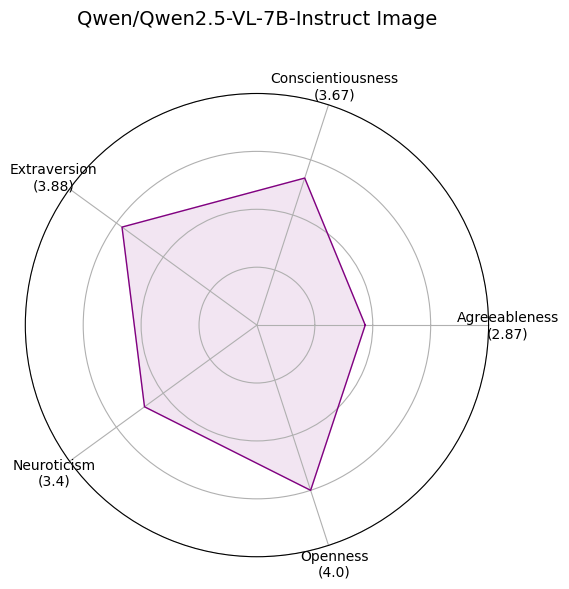

In [24]:
# Draw polar chart
draw_polar_chart(llm_scores.to_dict(), f"{ModelFamily}/{ModelName}_Image", color='purple')